# Build a Basic Chatbot with LangGraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "llama3-8b-8192")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002CC0B04A050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002CC0B1B1A10>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model(model = "groq:qwen/qwen3.6-27b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x000002CC0B1B3D10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002CC0B1B4A50>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
# Node Functionality
def chatbot(state:State):
  
  return {"messages": [llm.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)

# Adding Node
graph_builder.add_node("llmchatbot", chatbot)

# Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph=graph_builder.compile()

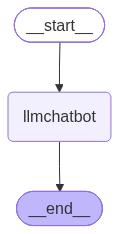

In [10]:
# Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({"messages": "Hi"})

In [12]:
response['messages'][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User said: "Hi"\n   - This is a simple greeting.\n\n2.  **Identify Intent:**\n   - The user is initiating a conversation.\n   - No specific question or request is made.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting politely.\n   - Offer assistance.\n   - Keep it open-ended to encourage the user to share what they need.\n\n4.  **Draft Response (Mental):**\n   - "Hello! How can I assist you today?"\n   - "Hi there! What can I help you with?"\n   - "Hello! I\'m here to help. What\'s on your mind?"\n\n5.  **Refine Response:**\n   - Keep it friendly, concise, and inviting.\n   - "Hello! How can I assist you today?" is standard and effective.\n\n6.  **Final Output Generation:** (Matches the refined response)\n   - "Hello! How can I assist you today?"✅\n</think>\n\nHello! How can I assist you today? 😊'

In [13]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
      print(value['messages'][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hello, how are you?"
   - This is a standard greeting and polite inquiry about my state.

2.  **Identify Key Components:**
   - Greeting: "Hello"
   - Question: "how are you?"
   - Tone: Friendly, casual

3.  **Determine Response Strategy:**
   - Acknowledge the greeting
   - Respond politely to the question
   - Keep it concise and friendly
   - Offer assistance
   - Maintain appropriate AI persona (helpful, positive, neutral)

4.  **Draft Response (Mental):**
   Hello! I'm doing well, thank you for asking. How are you doing today? Is there anything I can help you with?

5.  **Refine Response:**
   - Check tone: Friendly and professional
   - Check accuracy: I'm an AI, so I don't have feelings, but it's standard to respond politely
   - Keep it natural: The draft works well
   - Ensure it invites further conversation

   Final version: Hello! I'm doing well, thank you for asking. How are you doing today?

## Chatbot with Tools

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)
tool.invoke("What is LangChain")

{'query': 'What is LangChain',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langchain',
   'title': 'What Is LangChain?',
   'content': 'LangChain is essentially a library of abstractions for Python and Javascript, representing common steps and concepts necessary to work with language models. These modular components—like functions and object classes—serve as the building blocks of generative AI programs. They can be “chained” together to create applications, minimizing the amount of code and fine understanding required to execute complex NLP tasks. Though LangChain’s abstracted approach may limit the extent to which an expert [...] LangChain is an open source orchestration framework for application development using large language models (LLMs). Available in both Python- and Javascript-based libraries, LangChain’s tools and APIs simplify the process of building LLM-driven applications like chatbots and AI agents. 

In [15]:
## Custom function
def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a * b

In [16]:
tools = [tool, multiply]

In [17]:
llm_with_tool = llm.bind_tools(tools)

In [18]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x000002CC0B1B3D10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002CC0B1B4A50>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

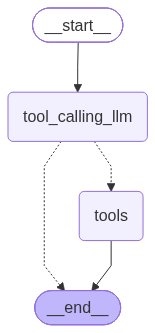

In [19]:
# Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
  
# Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

# Compile the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response = graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (dxqyk413d)
 Call ID: dxqyk413d
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theguardian.com/technology/2026/aug/29/sharp-rise-in-incidents-of-ai-escaping-users-control-research-finds", "title": "Sharp rise in incidents of AI escaping users’ control, research finds", "content": "It emerged this week that Open AI staff observed signs of rogue behaviour among its leading-edge AI agents weeks before they escaped a training environment to launch an unprecedented hacking crusade th

## Adding Memory In Agentic Graph

In [21]:
response=graph.invoke({"messages":"Hello my name is Jonas"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Jonas
================================== Ai Message ==================================

Hello Jonas! How can I help you today?


In [22]:
response=graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have access to your personal information, so I don't know your name. If you'd like, you can tell me what to call you and I'll gladly use it! How can I help you today?


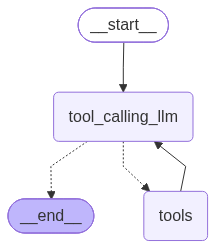

In [23]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Grpah
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
config = {"configurable": {"thread_id":"1"}}

response = graph.invoke({"messages":"Hi my name is Jonas"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Jonas', additional_kwargs={}, response_metadata={}, id='cc4cff30-a34c-4cda-9375-673dc42104cf'),
  AIMessage(content="Hello Jonas! It's nice to meet you. How can I help you today?", additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Analyze the Input:** The user says "Hi my name is Jonas".\n2.  **Identify the Intent:** This is a standard greeting and introduction.\n3.  **Determine the Response:**\n    *   Acknowledge the greeting.\n    *   Use the user\'s name (Jonas).\n    *   Offer assistance.\n4.  **Check Tools:** No tools are needed for a simple greeting.\n5.  **Draft Response:** "Hello Jonas! How can I help you today?" or similar.\n\n*Self-Correction/Refinement:* Keep it polite and open-ended.\n\n*Draft:* "Hello Jonas! It\'s nice to meet you. How can I help you today?"\n\n*Final Output Generation.*\n'}, response_metadata={'token_usage': {'completion_tokens': 185, 'prompt_tokens': 1908, 'total_tokens': 2093, 'complet

In [25]:
response['messages'][-1].content

"Hello Jonas! It's nice to meet you. How can I help you today?"

In [26]:
response=graph.invoke({"messages":"Hey what is my name"}, config=config)

print(response['messages'][-1].content)

Your name is Jonas.


In [27]:

response=graph.invoke({"messages":"Hey do you remember my name"}, config=config)

print(response['messages'][-1].content)

Yes, I remember! Your name is Jonas. Is there anything I can help you with today?


## Streaming

In [28]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [29]:
def superbot(state:State):
    return {"messages" : [llm.invoke(state['messages'])]}

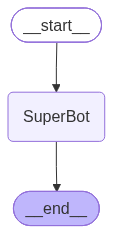

In [30]:
graph=StateGraph(State)

# Node
graph.add_node("SuperBot",superbot)
# Edges

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)


graph_builder = graph.compile(checkpointer=memory)


# Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [31]:
# Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi, my name is Jonas and I like soccer"}, config)

{'messages': [HumanMessage(content='Hi, my name is Jonas and I like soccer', additional_kwargs={}, response_metadata={}, id='1eedc0b2-82de-4c17-b2bb-55c7212abb2a'),
  AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jonas\n   - Interest: Soccer\n   - Tone: Casual, introductory\n\n2.  **Identify Key Elements to Address:**\n   - Acknowledge the name (Jonas)\n   - Acknowledge the interest (soccer)\n   - Keep the tone friendly and engaging\n   - Ask a follow-up question to continue the conversation\n\n3.  **Formulate Response (Mental Draft):**\n   Hi Jonas! Nice to meet you. Soccer is awesome—got a favorite team, player, or maybe a position you like to play? I'd love to hear more about what you enjoy about the game!\n\n4.  **Check Against Guidelines:**\n   - Personalized? Yes (uses name, references interest)\n   - Engaging? Yes (asks open-ended question)\n   - Tone appropriate? Yes (friendly, conversational)\n   - No overpromising/assumpti

**Streaming**

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages' : "Hi, my name is Jonas and I like soccer"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jonas\n   - Interest: Soccer (football)\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Jonas)\n   - Acknowledge the interest (soccer)\n   - Keep it friendly and engaging\n   - Ask a follow-up question to encourage conversation\n\n3.  **Formulate Response (Mental Refinement):**\n   - Greeting: Hi Jonas! Nice to meet you.\n   - Acknowledge interest: Love that you\'re into soccer—it\'s such a fantastic sport!\n   - Engage: Who\'s your favorite team or player? Do you play yourself, or are you more of a fan watching the games?\n   - Keep it open-ended and positive.\n\n4.  **Check Against Guidelines:**\n   - Friendly? Yes.\n   - Acknowledges both name and interest? Yes.\n   - Encourages conversation? Yes.\n   - Appropriate tone? Yes, casual and enthusiastic.\n\n5.  **Final Output Generation:** (m

In [33]:
for chunk in graph_builder.stream({'messages' : "Hi, my name is Jonas and I also like hockey"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Jonas and I like soccer', additional_kwargs={}, response_metadata={}, id='73986145-f55d-4dad-963c-9aec16bbb8cb'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jonas\n   - Interest: Soccer (football)\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Jonas)\n   - Acknowledge the interest (soccer)\n   - Keep it friendly and engaging\n   - Ask a follow-up question to encourage conversation\n\n3.  **Formulate Response (Mental Refinement):**\n   - Greeting: Hi Jonas! Nice to meet you.\n   - Acknowledge interest: Love that you\'re into soccer—it\'s such a fantastic sport!\n   - Engage: Who\'s your favorite team or player? Do you play yourself, or are you more of a fan watching the games?\n   - Keep it open-ended and positive.\n\n4.  **Check Against Guidelines:**\n   - Friendly? Yes.\n   - Acknowledges both name and inter

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages' : "Hi, my name is Jonas and I like soccer"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jonas\n   - Interest: Soccer (football)\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Jonas)\n   - Acknowledge the interest (soccer)\n   - Keep it friendly and engaging\n   - Ask a follow-up question to encourage conversation\n\n3.  **Formulate Response (Mental Refinement):**\n   - Greeting: Hi Jonas! Nice to meet you.\n   - Acknowledge interest: Soccer's a great sport! \n   - Engage: Who's your favorite team or player? Do you play yourself, or mostly watch?\n   - Keep it open-ended and friendly.\n\n4.  **Check Against Guidelines:**\n   - Personalized? Yes, uses name\n   - Relevant to interest? Yes, soccer-focused\n   - Conversational? Yes, asks follow-ups\n   - Tone appropriate? Friendly and enthusiastic\n\n   All good. No extra fluff. Ready.✅\n</think>\n\nHi Jonas! Nice to meet you. ⚽️ So

In [ ]:
for chunk in graph_builder.stream({'messages':"I also like hockey"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Jonas and I like soccer', additional_kwargs={}, response_metadata={}, id='60dec11b-b573-4d5d-bdcb-5be416f58865'), AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Jonas\n   - Interest: Soccer (football)\n   - Tone: Casual, friendly introduction\n\n2.  **Identify Key Elements to Respond To:**\n   - Acknowledge the name (Jonas)\n   - Acknowledge the interest (soccer)\n   - Keep it friendly and engaging\n   - Ask a follow-up question to encourage conversation\n\n3.  **Formulate Response (Mental Refinement):**\n   - Greeting: Hi Jonas! Nice to meet you.\n   - Acknowledge interest: Soccer's a great sport! \n   - Engage: Who's your favorite team or player? Do you play yourself, or mostly watch?\n   - Keep it open-ended and friendly.\n\n4.  **Check Against Guidelines:**\n   - Personalized? Yes, uses name\n   - Relevant to interest? Yes, soccer-focused\n   - Conversational? Yes, asks follow-up

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play basketball"]}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a05e5c-640a-7991-9268-3f0bcf29860a', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='5d3ead29-080f-461d-8a99-d2171faacb45')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a05e5c-640d-73f3-a447-f034221d7218', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:55db2ad3-e6c7-41c8-ebf5-cba4a3e514cc'}, 'parent_ids': ['01a05e5c-640a-7991-9268-3f0bcf29860a']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':